# Model Evaluation, Explainability, and Fairness Reflection  
## Decision Tree Classification on Library Late Return Dataset

**Assignment 6**  

This notebook evaluates a machine learning classification model, explains its predictions, analyzes model errors, checks overfitting and underfitting, and reflects on fairness and bias. The dataset used is a library borrower dataset where the goal is to predict whether a borrowed item will be returned late.

## Business Problem

Libraries need to manage borrowed items effectively so that books remain available for other users. Late returns can reduce service quality, increase administrative work, and create inconvenience for other borrowers. A machine learning model can support the library by identifying borrowers who may be at risk of returning books late.

The model in this assignment predicts whether a borrower will return a borrowed item late.

- **Target variable:** `late_return`
- **Class 0:** On-time return
- **Class 1:** Late return

This model should be treated as a decision-support tool, not as an automatic punishment system.

In [5]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Explainability libraries
import shap
from lime.lime_tabular import LimeTabularExplainer

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

# Task 1: Load and Understand the Dataset

In [6]:
# Load dataset
file_path = "library_late_return_dataset.csv"
df = pd.read_csv(file_path)

# Basic inspection
print("Dataset size:", df.shape)
display(df.head())

Dataset size: (360, 17)


,borrower_id,age,age_group,gender,region,membership_type,borrower_category,book_category,loan_period_days,books_borrowed_last_6m,previous_late_returns,days_before_due_reminder_sent,account_fines_amount,library_visits_last_3m,renewal_used,distance_to_library_km,late_return
0,LB0001,56,51+,Male,North,Standard,Regular,Children,21,26,1,7,35.99,12,No,15.1,0
1,LB0002,72,51+,Male,West,Standard,Research,Textbook,14,32,1,1,NaN,3,Yes,19.0,0
2,LB0003,67,51+,Male,West,Standard,Casual,Technology,7,31,0,7,81.32,6,Yes,1.7,0
3,LB0004,80,51+,Female,West,Senior,Casual,Textbook,28,21,0,3,80.22,2,Yes,24.4,1
4,LB0005,23,18-25,Female,East,Standard,Regular,Non-fiction,14,28,0,3,81.72,14,Yes,9.3,0


In [7]:
# Column names and data types
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values})
display(data_types)

,Column,Data Type
0,borrower_id,object
1,age,int64
2,age_group,object
3,gender,object
4,region,object
5,membership_type,object
6,borrower_category,object
7,book_category,object
8,loan_period_days,int64
9,books_borrowed_last_6m,int64


In [8]:
# Missing values
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ["Column", "Missing Values"]
display(missing_values)

# Duplicate records
duplicate_count = df.duplicated().sum()
print("Duplicate records:", duplicate_count)

,Column,Missing Values
0,borrower_id,0
1,age,0
2,age_group,0
3,gender,0
4,region,0
5,membership_type,0
6,borrower_category,0
7,book_category,0
8,loan_period_days,0
9,books_borrowed_last_6m,0


Duplicate records: 0


,Class,Count,Percentage
0,On Time Return (0),209,58.055556
1,Late Return (1),151,41.944444


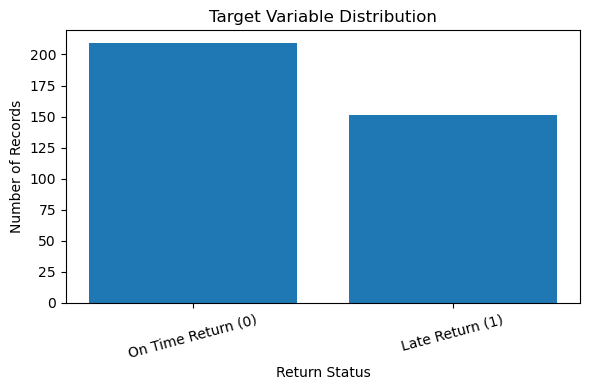

In [9]:
# Target variable distribution
target_counts = df["late_return"].value_counts().sort_index()
target_distribution = pd.DataFrame({
    "Class": ["On Time Return (0)", "Late Return (1)"],
    "Count": [target_counts.get(0, 0), target_counts.get(1, 0)],
    "Percentage": [target_counts.get(0, 0) / len(df) * 100, target_counts.get(1, 0) / len(df) * 100]})
display(target_distribution)

plt.figure(figsize=(6,4))
plt.bar(target_distribution["Class"], target_distribution["Count"])
plt.title("Target Variable Distribution")
plt.xlabel("Return Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Task 1 Interpretation

The dataset contains borrower and loan-related information for library users. The target variable is `late_return`, which identifies whether the borrower returned the item late. A value of 1 means late return, and a value of 0 means on-time return.

The target variable is reasonably balanced because both classes have a meaningful number of records. However, there are slightly more on-time returns than late returns. This means accuracy alone is not enough. Precision, recall, F1-score, and error analysis are also needed to understand the model properly.

# Task 2: Define Features and Target Variable

In [10]:
# Define target, identifier, and fairness columns
target_column = "late_return"
identifier_columns = ["borrower_id"]
fairness_columns = ["gender", "age_group"]

# Columns removed from model input
removed_from_model = identifier_columns + fairness_columns

# Feature columns used for training
feature_columns = [col for col in df.columns if col not in removed_from_model + [target_column]]

print("Target variable:", target_column)
print("Identifier columns removed:", identifier_columns)
print("Fairness columns kept only for fairness reflection:", fairness_columns)
print("Input features used for model training:")
for col in feature_columns:
    print("-", col)

X = df[feature_columns]
y = df[target_column]
fairness_df = df[fairness_columns].copy()

Target variable: late_return
Identifier columns removed: ['borrower_id']
Fairness columns kept only for fairness reflection: ['gender', 'age_group']
Input features used for model training:
- age
- region
- membership_type
- borrower_category
- book_category
- loan_period_days
- books_borrowed_last_6m
- previous_late_returns
- days_before_due_reminder_sent
- account_fines_amount
- library_visits_last_3m
- renewal_used
- distance_to_library_km


### Task 2 Interpretation

The target variable is `late_return` because the purpose of the model is to predict whether a library item will be returned late. The model input uses borrower behavior, loan details, library usage, and location-related information.

The column `borrower_id` is removed because it is only an identifier and does not provide general learning value. The fairness-related columns `gender` and `age_group` are not used as model inputs. They are kept separately only to evaluate whether the model behaves differently across groups. This is important because group-related columns can create fairness and bias concerns if used directly for prediction.

# Task 3: Data Preprocessing

In [11]:
# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing for numerical and categorical columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)])

Numerical features: ['age', 'loan_period_days', 'books_borrowed_last_6m', 'previous_late_returns', 'days_before_due_reminder_sent', 'account_fines_amount', 'library_visits_last_3m', 'distance_to_library_km']
Categorical features: ['region', 'membership_type', 'borrower_category', 'book_category', 'renewal_used']


### Task 3 Interpretation

Preprocessing is necessary because machine learning models cannot directly use raw text categories such as region, membership type, or book category. These categorical variables must be converted into numeric form using one-hot encoding. Missing values must also be handled because many machine learning algorithms cannot train properly when missing values are present.

In this notebook, numerical missing values are filled using the median, and categorical missing values are filled using the most frequent category. This creates a clean final feature set for model training.

# Task 4: Train/Test Split

In [12]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test, fairness_train, fairness_test = train_test_split(
    X, y, fairness_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Training target distribution:")
print(y_train.value_counts(normalize=True).sort_index())
print("Testing target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set size: 288
Testing set size: 72
Training target distribution:
late_return
0    0.579861
1    0.420139
Name: proportion, dtype: float64
Testing target distribution:
late_return
0    0.583333
1    0.416667
Name: proportion, dtype: float64


### Task 4 Interpretation

The dataset is divided into training and testing data so that the model can be evaluated on records it has not already seen. The training data is used to teach the model patterns. The testing data is used to evaluate whether the model can generalize to new borrowers.

A stratified split is used so that the proportion of late and on-time returns remains similar in both the training and testing sets.

# Task 5: Train a Classification Model

In [13]:
# Build a Decision Tree model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=10,
        random_state=RANDOM_STATE))])

# Train model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Actual vs predicted comparison table
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Prediction Probability Late": y_pred_proba.round(3),
    "Correct Prediction": np.where(y_test.values == y_pred, "Correct", "Incorrect")})

display(prediction_comparison.head(15))

,Actual,Predicted,Prediction Probability Late,Correct Prediction
0,0,0,0.071,Correct
1,1,1,0.625,Correct
2,0,0,0.071,Correct
3,0,0,0.071,Correct
4,1,1,0.579,Correct
5,1,1,1.000,Correct
6,1,1,1.000,Correct
7,0,0,0.071,Correct
8,0,0,0.174,Correct
9,1,0,0.174,Incorrect


### Task 5 Interpretation

The Decision Tree model is trying to learn patterns that separate late returns from on-time returns. It uses borrower behavior, borrowing history, library visits, reminder timing, and other loan-related features to make predictions.

The comparison table shows the actual result and the model prediction for the first test records. A prediction is correct when the actual value and predicted value match. A prediction is incorrect when the model predicts the wrong return status.

# Task 6: Evaluate the Model

In [14]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]})
metrics_table["Score"] = metrics_table["Score"].round(4)
display(metrics_table)

print(classification_report(y_test, y_pred, target_names=["On Time Return", "Late Return"]))

,Metric,Score
0,Accuracy,0.5972
1,Precision,0.5161
2,Recall,0.5333
3,F1-score,0.5246


                precision    recall  f1-score   support

On Time Return       0.66      0.64      0.65        42
   Late Return       0.52      0.53      0.52        30

      accuracy                           0.60        72
     macro avg       0.59      0.59      0.59        72
  weighted avg       0.60      0.60      0.60        72



### Task 6 Interpretation

**Accuracy** shows the percentage of all test records that the model predicted correctly.  
**Precision** shows how many borrowers predicted as late were actually late.  
**Recall** shows how many actual late returns the model successfully detected.  
**F1-score** balances precision and recall into one score.

For this business problem, **recall** is the most important metric because the library wants to identify borrowers who may return items late. If recall is low, many late returns will be missed, and the library loses the opportunity to send reminders or take preventive action.

# Task 7: Confusion Matrix

,Predicted On Time (0),Predicted Late (1)
Actual On Time (0),27,15
Actual Late (1),14,16


True Negative: 27
False Positive: 15
False Negative: 14
True Positive: 16


<Figure size 500x400 with 0 Axes>

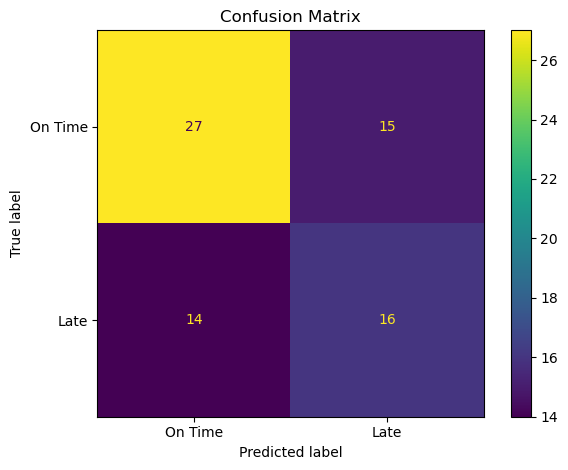

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_table = pd.DataFrame(
    cm,
    index=["Actual On Time (0)", "Actual Late (1)"],
    columns=["Predicted On Time (0)", "Predicted Late (1)"])
display(cm_table)

TN, FP, FN, TP = cm.ravel()
print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive:", TP)

# Visualization
plt.figure(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On Time", "Late"])
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Task 7 Interpretation

A **true negative** means the borrower returned the item on time and the model correctly predicted on-time return.  
A **false positive** means the borrower actually returned the item on time, but the model incorrectly predicted a late return.  
A **false negative** means the borrower actually returned the item late, but the model incorrectly predicted an on-time return.  
A **true positive** means the borrower returned the item late and the model correctly predicted a late return.

For this dataset, a **false negative** is more serious because the library fails to identify a borrower who may return an item late. This means the library may miss the chance to send additional reminders or support. False positives are also important because they may cause unnecessary reminders, but they are usually less costly than missed late returns.

# Task 8: Error Analysis

In [16]:
# Create error analysis table
error_analysis = X_test.copy().reset_index(drop=True)
error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred
error_analysis["Prediction Probability Late"] = y_pred_proba.round(3)
error_analysis["Prediction Status"] = np.where(error_analysis["Actual"] == error_analysis["Predicted"], "Correct", "Incorrect")

def classify_error(row):
    if row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"
    elif row["Actual"] == 1 and row["Predicted"] == 0:
        return "False Negative"
    else:
        return "True Positive"

error_analysis["Error Type"] = error_analysis.apply(classify_error, axis=1)

display(error_analysis[["Actual", "Predicted", "Prediction Status", "Error Type", "Prediction Probability Late"]].head(20))

error_type_counts = error_analysis["Error Type"].value_counts().reset_index()
error_type_counts.columns = ["Error Type", "Count"]
display(error_type_counts)

,Actual,Predicted,Prediction Status,Error Type,Prediction Probability Late
0,0,0,Correct,True Negative,0.071
1,1,1,Correct,True Positive,0.625
2,0,0,Correct,True Negative,0.071
3,0,0,Correct,True Negative,0.071
4,1,1,Correct,True Positive,0.579
5,1,1,Correct,True Positive,1.000
6,1,1,Correct,True Positive,1.000
7,0,0,Correct,True Negative,0.071
8,0,0,Correct,True Negative,0.174
9,1,0,Incorrect,False Negative,0.174


,Error Type,Count
0,True Negative,27
1,True Positive,16
2,False Positive,15
3,False Negative,14


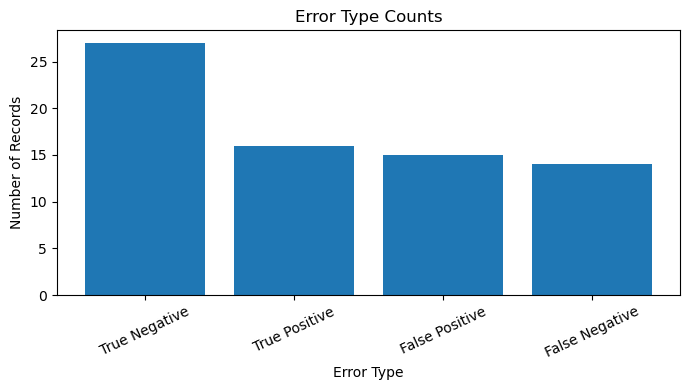

,age,region,membership_type,borrower_category,book_category,loan_period_days,books_borrowed_last_6m,previous_late_returns,days_before_due_reminder_sent,account_fines_amount,library_visits_last_3m,renewal_used,distance_to_library_km,Actual,Predicted,Prediction Probability Late,Prediction Status,Error Type
9,78,South,Student,Regular,Fiction,7,11,0,2,57.91,5,Yes,39.9,1,0,0.174,Incorrect,False Negative
16,44,North,Premium,Regular,Children,28,18,1,7,13.58,6,No,29.8,1,0,0.500,Incorrect,False Negative
17,22,East,Senior,Family,Textbook,28,17,0,5,54.56,12,No,2.2,1,0,0.300,Incorrect,False Negative
23,32,West,Standard,Regular,Fiction,7,19,2,2,25.82,5,Yes,23.5,1,0,0.200,Incorrect,False Negative
24,46,West,Senior,Family,Children,14,8,0,5,61.55,17,No,15.6,0,1,0.744,Incorrect,False Positive
25,64,North,Student,Family,Technology,7,27,0,2,48.29,4,No,6.0,0,1,0.744,Incorrect,False Positive
26,24,West,Premium,Casual,Technology,21,31,4,1,34.62,14,No,24.1,1,0,0.200,Incorrect,False Negative
29,25,North,Student,Family,Textbook,21,30,0,3,42.34,17,Yes,32.0,0,1,0.579,Incorrect,False Positive
32,29,North,Standard,Regular,Fiction,7,12,0,1,84.89,16,Yes,17.7,0,1,0.579,Incorrect,False Positive
34,23,South,Senior,Regular,Children,28,18,0,7,72.01,1,Yes,28.2,0,1,0.579,Incorrect,False Positive


In [17]:
# Visualize error type counts
plt.figure(figsize=(7,4))
plt.bar(error_type_counts["Error Type"], error_type_counts["Count"])
plt.title("Error Type Counts")
plt.xlabel("Error Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# Table of wrong predictions only
wrong_predictions = error_analysis[error_analysis["Prediction Status"] == "Incorrect"].copy()
display(wrong_predictions.head(20))

### Task 8 Interpretation

Error analysis shows where the model makes mistakes. The most important errors are false negatives and false positives. False negatives are late borrowers predicted as on-time. False positives are on-time borrowers predicted as late.

The most common wrong prediction type should be reviewed carefully because it shows the main weakness of the model. If false negatives are common, the library may miss borrowers who need reminders. If false positives are common, the library may send unnecessary reminders to borrowers who would have returned items on time anyway.

# Task 9: Cross-Validation

,Fold,Accuracy
0,1,0.6389
1,2,0.7361
2,3,0.8194
3,4,0.7222
4,5,0.7361


Mean cross-validation accuracy: 0.7306
Standard deviation: 0.0573


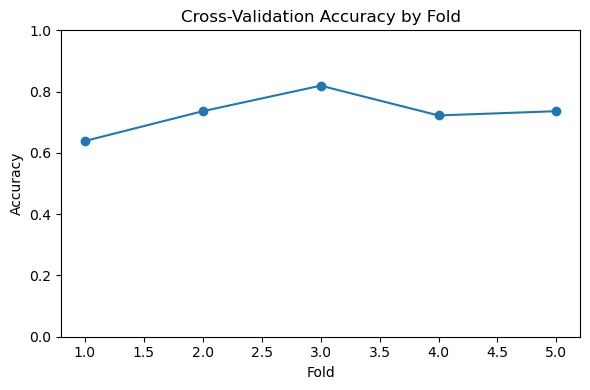

In [18]:
# Cross-validation accuracy
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores})
cv_table["Accuracy"] = cv_table["Accuracy"].round(4)
display(cv_table)

print("Mean cross-validation accuracy:", round(cv_scores.mean(), 4))
print("Standard deviation:", round(cv_scores.std(), 4))

plt.figure(figsize=(6,4))
plt.plot(cv_table["Fold"], cv_table["Accuracy"], marker="o")
plt.title("Cross-Validation Accuracy by Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Task 9 Interpretation

Cross-validation evaluates the model across different splits of the dataset. This is useful because a single train/test split may give a performance result that is too optimistic or too pessimistic.

If the fold scores are close together and the standard deviation is small, the model is relatively stable. If the fold scores vary widely, the model may be sensitive to how the data is split and may need improvement.

# Task 10: Overfitting and Underfitting Analysis

In [19]:
# Training and testing accuracy for selected model
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training accuracy:", round(train_accuracy, 4))
print("Testing accuracy:", round(test_accuracy, 4))
print("Accuracy gap:", round(train_accuracy - test_accuracy, 4))

Training accuracy: 0.8194
Testing accuracy: 0.5972
Accuracy gap: 0.2222


,Tree Depth,Training Accuracy,Testing Accuracy
0,1,0.7049,0.7639
1,2,0.7049,0.7639
2,3,0.7951,0.7222
3,4,0.8194,0.5972
4,5,0.8333,0.6250
5,6,0.8438,0.6528
6,7,0.8438,0.6528
7,8,0.8438,0.6528
8,9,0.8438,0.6528
9,10,0.8438,0.6528


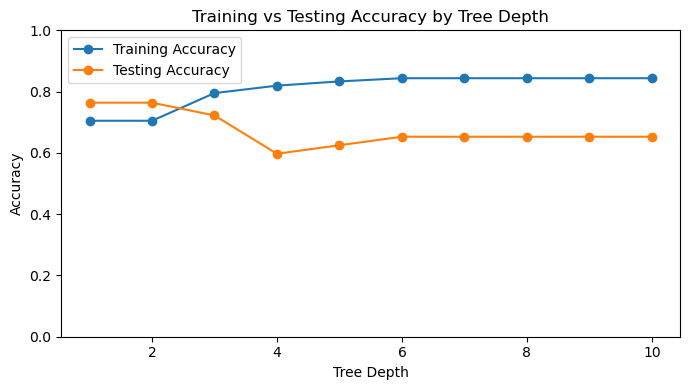

In [20]:
# Compare model performance with different tree depths
depth_results = []
for depth in range(1, 11):
    depth_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=10,
            random_state=RANDOM_STATE))])
    depth_model.fit(X_train, y_train)
    depth_results.append({
        "Tree Depth": depth,
        "Training Accuracy": depth_model.score(X_train, y_train),
        "Testing Accuracy": depth_model.score(X_test, y_test)})

depth_results_df = pd.DataFrame(depth_results)
display(depth_results_df.round(4))

plt.figure(figsize=(7,4))
plt.plot(depth_results_df["Tree Depth"], depth_results_df["Training Accuracy"], marker="o", label="Training Accuracy")
plt.plot(depth_results_df["Tree Depth"], depth_results_df["Testing Accuracy"], marker="o", label="Testing Accuracy")
plt.title("Training vs Testing Accuracy by Tree Depth")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

### Task 10 Interpretation

Overfitting happens when the model performs very well on training data but much worse on testing data. Underfitting happens when the model performs poorly on both training and testing data.

The selected Decision Tree uses a limited depth and minimum leaf size to reduce overfitting. The comparison across tree depths shows how increasing tree complexity can improve training accuracy but may not always improve testing accuracy. A large gap between training and testing accuracy would suggest overfitting.

# Task 11: Feature Importance

,Feature,Importance
3,previous_late_returns,0.362469
5,account_fines_amount,0.273118
26,renewal_used_Yes,0.113885
0,age,0.109607
7,distance_to_library_km,0.106224
25,renewal_used_No,0.032393
2,books_borrowed_last_6m,0.002304
4,days_before_due_reminder_sent,0.000000
17,borrower_category_Family,0.000000
24,book_category_Textbook,0.000000


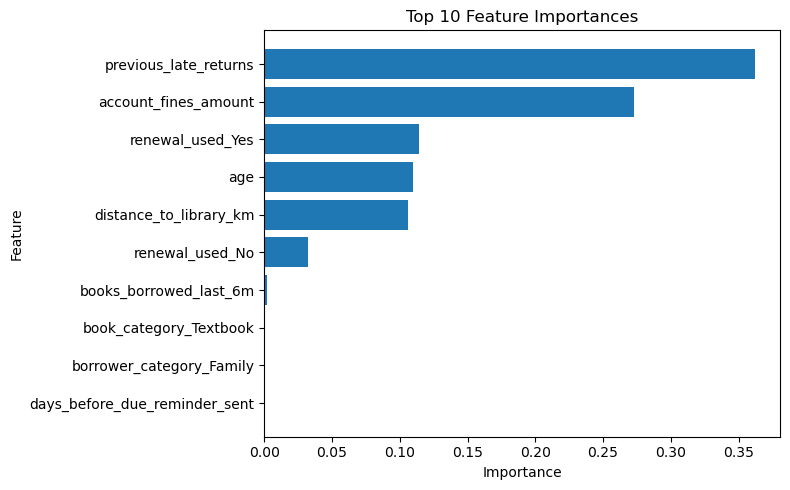

In [21]:
# Get feature names after preprocessing
fitted_preprocessor = model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
feature_names_clean = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

# Feature importance from trained Decision Tree
importances = model.named_steps["classifier"].feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": feature_names_clean,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Show only non-zero or top features
display(feature_importance_df.head(15))

plt.figure(figsize=(8,5))
top_features = feature_importance_df.head(10).sort_values("Importance")
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Task 11 Interpretation

Feature importance shows which variables the Decision Tree used most strongly when making predictions. For example, features related to previous late returns, fines, reminder timing, borrowing history, or library visits may be important because they reflect borrower behavior and risk.

However, feature importance does **not** prove cause and effect. A feature may be useful for prediction, but that does not mean it directly causes late returns. Business users should interpret feature importance carefully and combine model results with human judgment.

# Task 12: SHAP Explanation

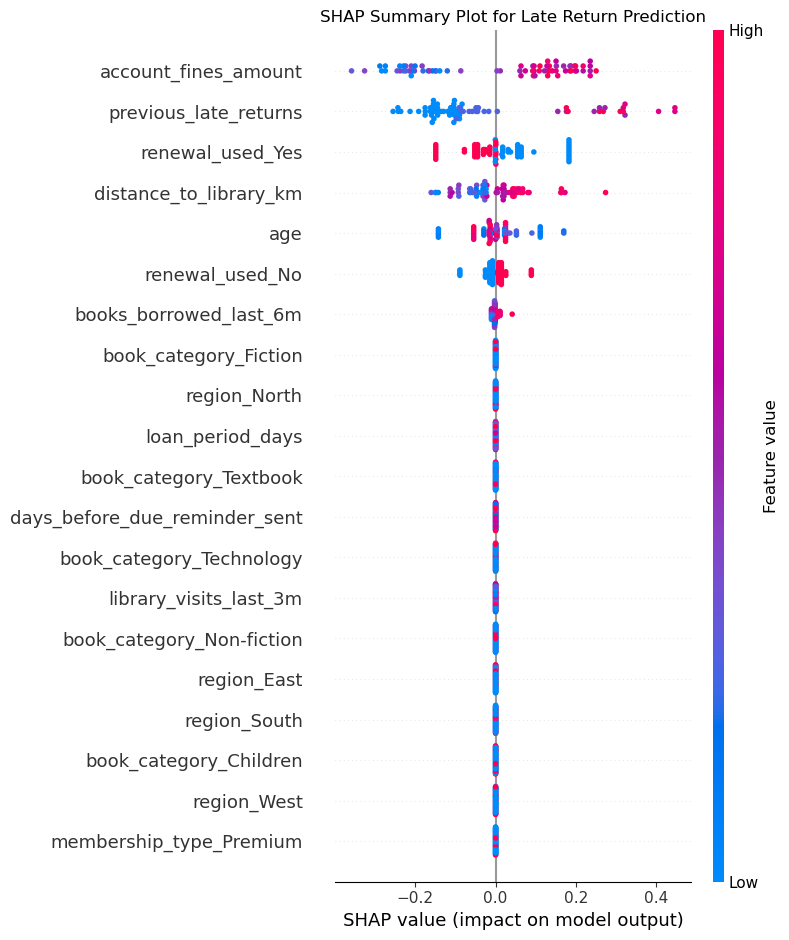

In [22]:
# Prepare transformed training and testing data for SHAP
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names_clean)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_clean)

# SHAP explanation for Decision Tree
explainer = shap.TreeExplainer(model.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_transformed_df)

# For binary classification, use SHAP values for class 1 when returned as a list
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

# SHAP summary plot
shap.summary_plot(shap_values_class1, X_test_transformed_df, show=False)
plt.title("SHAP Summary Plot for Late Return Prediction")
plt.tight_layout()
plt.show()

Selected test record index: 0
Actual value: 0
Predicted value: 0
Predicted probability of late return: 0.0714


,Feature,Feature Value,SHAP Value
5,account_fines_amount,34.81,-0.210143
3,previous_late_returns,0.00,-0.154722
0,age,23.00,0.022249
7,distance_to_library_km,24.40,0.018994
26,renewal_used_Yes,1.00,-0.014478
25,renewal_used_No,0.00,-0.007868
2,books_borrowed_last_6m,3.00,-0.002742
4,days_before_due_reminder_sent,7.00,0.000000
17,borrower_category_Family,0.00,0.000000
24,book_category_Textbook,0.00,0.000000


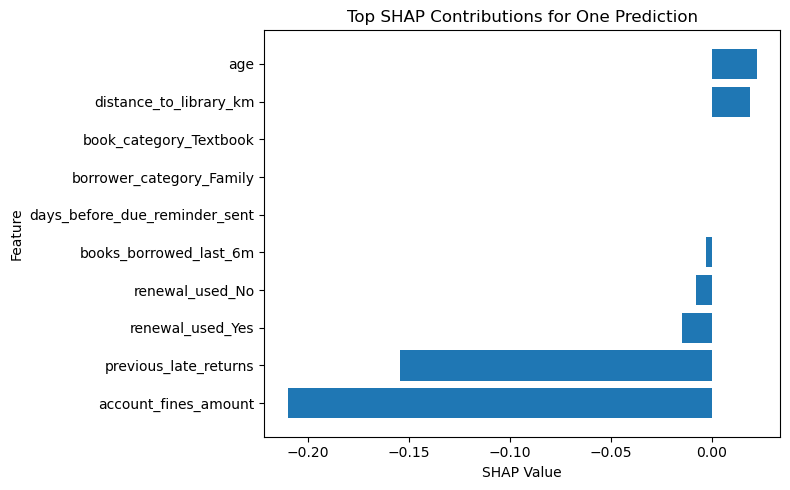

In [23]:
# SHAP explanation for one individual record
record_index = 0
individual_shap = pd.DataFrame({
    "Feature": feature_names_clean,
    "Feature Value": X_test_transformed_df.iloc[record_index].values,
    "SHAP Value": shap_values_class1[record_index]
}).sort_values(by="SHAP Value", key=abs, ascending=False)

print("Selected test record index:", record_index)
print("Actual value:", y_test.iloc[record_index])
print("Predicted value:", y_pred[record_index])
print("Predicted probability of late return:", round(y_pred_proba[record_index], 4))
display(individual_shap.head(10))

# Bar chart for individual SHAP values
individual_top = individual_shap.head(10).sort_values("SHAP Value")
plt.figure(figsize=(8,5))
plt.barh(individual_top["Feature"], individual_top["SHAP Value"])
plt.title("Top SHAP Contributions for One Prediction")
plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Task 12 Interpretation

SHAP helps explain how each feature pushes a prediction toward late return or toward on-time return. Unlike basic feature importance, SHAP can explain both the overall model behavior and one individual prediction.

For one selected borrower, positive SHAP values increase the model's prediction toward late return, while negative SHAP values decrease the prediction toward late return. This helps business users understand why the model gave a specific prediction instead of only seeing the final predicted class.

# Task 13: LIME Explanation

Prediction probability for selected record:
On-time return: 0.9286
Late return: 0.0714


,Feature Condition,LIME Weight
0,previous_late_returns <= 0.00,-0.250956
1,20.44 < account_fines_amount <= 43.04,-0.174796
2,0.00 < renewal_used_Yes <= 1.00,-0.119394
3,21.25 < distance_to_library_km <= 30.60,0.043714
4,renewal_used_No <= 0.00,-0.031002
5,borrower_category_Research <= 0.00,0.023149
6,book_category_Children <= 0.00,-0.018740
7,book_category_Textbook <= 0.00,0.018342
8,membership_type_Senior <= 0.00,0.014300
9,days_before_due_reminder_sent > 5.00,-0.013322


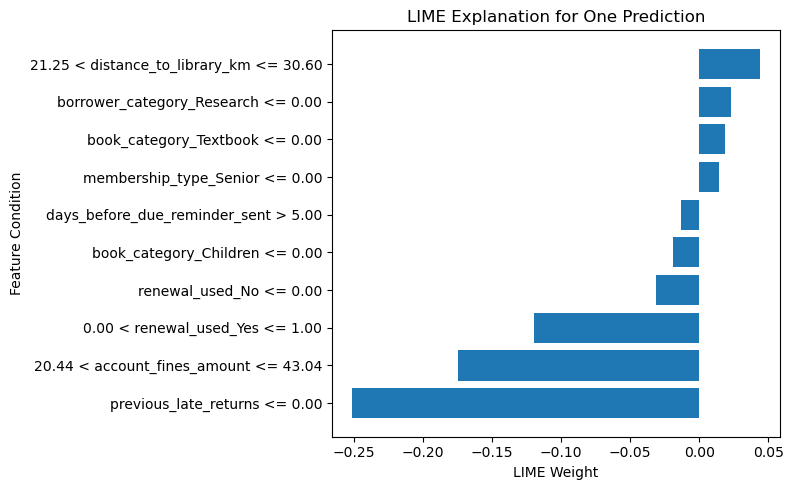

In [24]:
# LIME explanation for one individual prediction
class_names = ["On Time Return", "Late Return"]

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_transformed_df),
    feature_names=feature_names_clean,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE)

# Prediction function for transformed data
classifier_only = model.named_steps["classifier"]

selected_record = X_test_transformed_df.iloc[record_index].values
lime_exp = lime_explainer.explain_instance(
    data_row=selected_record,
    predict_fn=classifier_only.predict_proba,
    num_features=10)

print("Prediction probability for selected record:")
print("On-time return:", round(classifier_only.predict_proba([selected_record])[0][0], 4))
print("Late return:", round(classifier_only.predict_proba([selected_record])[0][1], 4))

lime_table = pd.DataFrame(lime_exp.as_list(), columns=["Feature Condition", "LIME Weight"])
display(lime_table)

# LIME visualization as bar chart
lime_plot_df = lime_table.copy().sort_values("LIME Weight")
plt.figure(figsize=(8,5))
plt.barh(lime_plot_df["Feature Condition"], lime_plot_df["LIME Weight"])
plt.title("LIME Explanation for One Prediction")
plt.xlabel("LIME Weight")
plt.ylabel("Feature Condition")
plt.tight_layout()
plt.show()

### Task 13 Interpretation

LIME explains one individual prediction by showing which feature conditions supported or worked against the predicted outcome. Positive LIME weights support the predicted class, while negative LIME weights work against it.

This is useful for business users because it translates a complex model decision into a local explanation for one borrower. For example, it can help library staff understand whether a late-return prediction was influenced by previous late returns, fines, reminders, or borrowing activity.

# Task 14: Fairness and Bias Reflection

In [25]:
# Add predictions and actual values to fairness test data
fairness_results = fairness_test.reset_index(drop=True).copy()
fairness_results["Actual"] = y_test.values
fairness_results["Predicted"] = y_pred
fairness_results["Correct"] = fairness_results["Actual"] == fairness_results["Predicted"]

# Function to calculate fairness metrics by group
def fairness_summary(data, group_col):
    summary = data.groupby(group_col).agg(
        Number_of_Records=("Actual", "count"),
        Actual_Positive_Rate=("Actual", "mean"),
        Predicted_Positive_Rate=("Predicted", "mean"),
        Accuracy_By_Group=("Correct", "mean")
    ).reset_index()
    return summary

fairness_gender = fairness_summary(fairness_results, "gender")
fairness_age_group = fairness_summary(fairness_results, "age_group")

print("Fairness analysis by gender:")
display(fairness_gender.round(4))

print("Fairness analysis by age group:")
display(fairness_age_group.round(4))

Fairness analysis by gender:


,gender,Number_of_Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy_By_Group
0,Female,31,0.4194,0.4194,0.5484
1,Male,41,0.4146,0.4390,0.6341


Fairness analysis by age group:


,age_group,Number_of_Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy_By_Group
0,18-25,18,0.3333,0.3333,0.3333
1,26-35,9,0.3333,0.3333,0.7778
2,36-50,9,0.5556,0.6667,0.6667
3,51+,36,0.4444,0.4444,0.6667


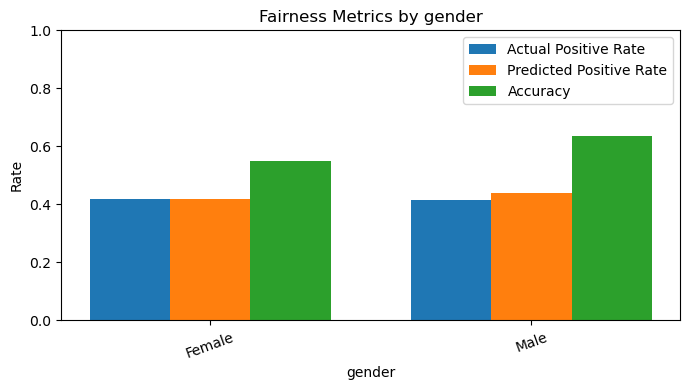

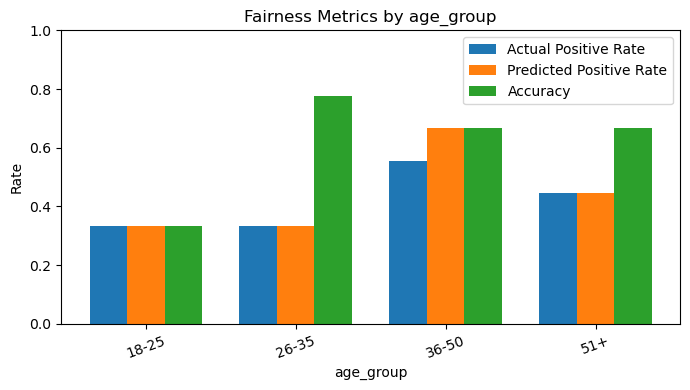

In [26]:
# Visualizations for fairness analysis
for group_col, summary_df in [("gender", fairness_gender), ("age_group", fairness_age_group)]:
    plt.figure(figsize=(7,4))
    x = np.arange(len(summary_df[group_col]))
    width = 0.25
    plt.bar(x - width, summary_df["Actual_Positive_Rate"], width, label="Actual Positive Rate")
    plt.bar(x, summary_df["Predicted_Positive_Rate"], width, label="Predicted Positive Rate")
    plt.bar(x + width, summary_df["Accuracy_By_Group"], width, label="Accuracy")
    plt.title(f"Fairness Metrics by {group_col}")
    plt.xlabel(group_col)
    plt.ylabel("Rate")
    plt.xticks(x, summary_df[group_col], rotation=20)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Task 14 Interpretation

Fairness analysis compares model behavior across different groups. In this notebook, fairness is reviewed using `gender` and `age_group`. These columns were not used to train the model, but they are used after prediction to check whether model performance differs across groups.

For each group, the analysis reports the number of records, actual positive rate, predicted positive rate, and accuracy. If one group has much lower accuracy than another group, or if the predicted positive rate is very different from the actual positive rate, the model may create unfair business decisions.

Even when fairness columns are removed from training, bias can still appear through other related variables. Therefore, the model should be monitored carefully before being used in real library decision-making.

# Task 15: Final Business Interpretation

In [27]:
# Collect important final results for summary
main_error_counts = error_analysis[error_analysis["Prediction Status"] == "Incorrect"]["Error Type"].value_counts()
main_error_type = main_error_counts.idxmax() if len(main_error_counts) > 0 else "No errors"
most_important_feature = feature_importance_df.iloc[0]["Feature"]

final_summary = pd.DataFrame({
    "Item": [
        "Model", "Target", "Accuracy", "Precision", "Recall", "F1-score",
        "Training Accuracy", "Testing Accuracy", "Main Error Type", "Most Important Feature"],
    "Result": [
        "Decision Tree Classifier", "late_return", round(accuracy, 4), round(precision, 4),
        round(recall, 4), round(f1, 4), round(train_accuracy, 4), round(test_accuracy, 4),
        main_error_type, most_important_feature]})
display(final_summary)

,Item,Result
0,Model,Decision Tree Classifier
1,Target,late_return
2,Accuracy,0.5972
3,Precision,0.5161
4,Recall,0.5333
5,F1-score,0.5246
6,Training Accuracy,0.8194
7,Testing Accuracy,0.5972
8,Main Error Type,False Positive
9,Most Important Feature,previous_late_returns


### Final Business Interpretation

The Decision Tree model predicts whether a library borrower will return a borrowed item late. This is useful because the library can use predictions to send earlier reminders, manage book availability, and reduce overdue items.

The model provides a reasonable first version because it produces interpretable results and can be explained using feature importance, SHAP, and LIME. The most important evaluation metric for this problem is recall because the library wants to identify as many actual late returns as possible. A false negative is more serious than a false positive because a borrower who is likely to return an item late may not receive extra reminders.

The confusion matrix and error analysis show the main types of mistakes made by the model. These mistakes have business consequences. False positives may cause unnecessary reminders, while false negatives may lead to missed late-return prevention opportunities.

The overfitting and underfitting analysis compares training and testing performance. If training accuracy is much higher than testing accuracy, the model may be overfitting. If both scores are low, the model may be underfitting. The tree depth comparison helps determine whether the model is too simple or too complex.

Feature importance shows which variables the model relies on most, but it does not prove cause and effect. SHAP gives a deeper explanation of how features push predictions toward late return or on-time return. LIME explains one individual prediction in a way that is easier for business users to understand.

Fairness analysis was completed for gender and age group. The model should not be used in real decision-making unless performance is reviewed across groups and unfair differences are addressed. Removing fairness columns from training is helpful, but it does not fully eliminate bias because other variables may still indirectly reflect group differences.

**Final recommendation:** This model is suitable as an early prototype and decision-support tool. It is not ready for fully automated business use. Before real deployment, the library should improve recall, test the model on more data, monitor fairness across borrower groups, and keep human review in the decision-making process.